# G5. Cross Comparison and Conclusions

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

It brings the four evaluation runs together and answers the questions the project set out with.
Nothing is retrained here; it reads what G3 and G4 wrote and compares along three axes.

- Training data: real against each of the four synthetic generators.
- Task: excellence, the top quarter, against underperformance, the bottom quarter.
- Mitigation: none, equalized odds, prejudice remover.

## The questions

1. How much accuracy is lost when training data is synthetic.
2. How much of the fairness profile changes.
3. Are the two losses related, and is there a generator that is acceptable on both.
4. Do the answers hold when the task is mirrored to the other tail.
5. Does fairness mitigation still work once the training data is synthetic.

The last two are the additions to the original proposal, and question 5 is the one with the
most practical weight: it asks whether the privacy motivated decision to use synthetic data
quietly undermines the fairness tooling applied afterwards.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

from src.data.persistence import save_csv
from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs

logger = get_logger("G5")
check_prerequisites()

cfg = load_config(PROJECT_ROOT / "config" / "config.yaml")
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, "g5")

TASKS = list(cfg["tasks"])
BASELINE = cfg["experiments"]["baseline_label"]
MITIGATION_ORDER = ["none"] + cfg["mitigation"]["methods"]

print(f"tasks      : {TASKS}")
print(f"mitigation : {MITIGATION_ORDER}")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
tasks      : ['high_perf', 'low_perf']
mitigation : ['none', 'equalized_odds', 'prejudice_remover']


## 2. Reading the four runs

SMOTE appears under two names, because it had to be run once per task. They are the same
technique, so the low perf variant is relabelled to line the two tasks up in one table.

In [2]:
def normalise_generator(name):
    """The two SMOTE outputs are one technique run twice, so they share a label here."""
    return "smote" if name == "smote_low_perf" else name


unmitigated = []
for task in TASKS:
    frame = pd.read_csv(cfg["paths"]["results_dir"] / "g3" / task / "metrics_matrix.csv")
    frame["task"] = task
    frame["mitigation"] = "none"
    unmitigated.append(frame)

unmitigated = pd.concat(unmitigated, ignore_index=True)
unmitigated["generator"] = unmitigated["method"].map(normalise_generator)
unmitigated["source"] = np.where(unmitigated["method"] == BASELINE, "real", "synthetic")

print(f"Unmitigated grids: {unmitigated.shape[0]} rows across {len(TASKS)} tasks")

Unmitigated grids: 30 rows across 2 tasks


In [3]:
mitigated = []
for task in TASKS:
    frame = pd.read_csv(cfg["paths"]["results_dir"] / "g4" / task / "mitigation_results.csv")
    frame["task"] = task
    mitigated.append(frame)

mitigated = pd.concat(mitigated, ignore_index=True)
mitigated = mitigated[mitigated["balanced_accuracy"].notna()]
mitigated["mitigation"] = mitigated["technique"]
mitigated["generator"] = mitigated["method"].map(normalise_generator)
mitigated["source"] = np.where(mitigated["method"] == BASELINE, "real", "synthetic")

# One mitigated fit exists per circumstance, so average over circumstances to get a single
# number per training set and classifier, comparable with the unmitigated grid.
shared = ["task", "mitigation", "generator", "source", "classifier"]
measures = ["balanced_accuracy", "f1_macro", "roc_auc", "mean_dpd", "mean_eod",
            "mean_di", "mean_odds_ratio"]
mitigated = mitigated.groupby(shared, as_index=False)[measures].mean()

combined = pd.concat(
    [unmitigated[shared + measures], mitigated[shared + measures]], ignore_index=True,
)
combined["mitigation"] = pd.Categorical(combined["mitigation"], MITIGATION_ORDER, ordered=True)

save_csv(combined, RESULTS_DIR / "combined_results.csv")
print(f"Combined: {combined.shape[0]} rows")

2026-07-28 14:38:12 | INFO     | src.data.persistence | Saved 70 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\combined_results.csv


Combined: 70 rows


## 3. Question 1, how much accuracy is lost

Balanced accuracy of each synthetic training set against the real baseline, on both tasks,
without any mitigation.

In [4]:
no_mitigation = combined[combined["mitigation"] == "none"]

utility = (
    no_mitigation.groupby(["task", "generator"], observed=True)["balanced_accuracy"]
    .mean().unstack("task").round(4)
)
real_row = utility.loc[BASELINE]
utility_loss = (utility - real_row).drop(index=BASELINE).round(4)

print("Mean balanced accuracy, averaged across the three classifiers:")
print(utility.to_string())
print("\nChange from the real baseline, negative means worse:")
print(utility_loss.to_string())

# Balanced accuracy starts at 0.5 for a coin flip, so the real baseline only holds a narrow
# band of usable signal above chance. Expressing the loss as a share of that band is what says
# how much of the signal a generator actually destroyed.
headroom = real_row - 0.5
share_lost = (-utility_loss / headroom).round(3)
print(f"\nSignal available above chance: {headroom.round(4).to_dict()}")
print("Share of it lost, 1.0 means the generator gave up everything the real data had:")
print(share_lost.to_string())

save_csv(utility.reset_index(), RESULTS_DIR / "utility_by_task.csv")

Mean balanced accuracy, averaged across the three classifiers:
task             high_perf  low_perf
generator                           
ctgan               0.5584    0.5768
gaussian_copula     0.4823    0.5552
real                0.6117    0.6059
smote               0.5718    0.5481
tvae                0.6033    0.6006

Change from the real baseline, negative means worse:
task             high_perf  low_perf
generator                           
ctgan              -0.0533   -0.0291
gaussian_copula    -0.1294   -0.0507
smote              -0.0399   -0.0578
tvae               -0.0084   -0.0053

Signal available above chance: {'high_perf': 0.1117, 'low_perf': 0.1059}
Share of it lost, 1.0 means the generator gave up everything the real data had:
task             high_perf  low_perf
generator                           
ctgan                0.477     0.275
gaussian_copula      1.158     0.479
smote                0.357     0.546
tvae                 0.075     0.050
2026-07-28 14:38:12 | INFO

2026-07-28 14:38:25 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\utility_by_task.png


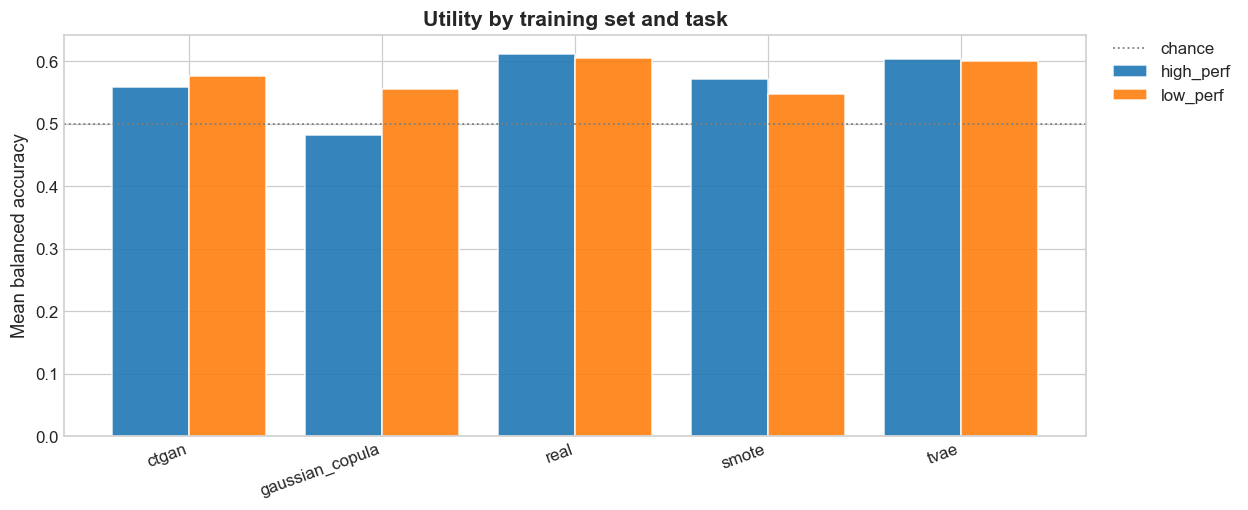

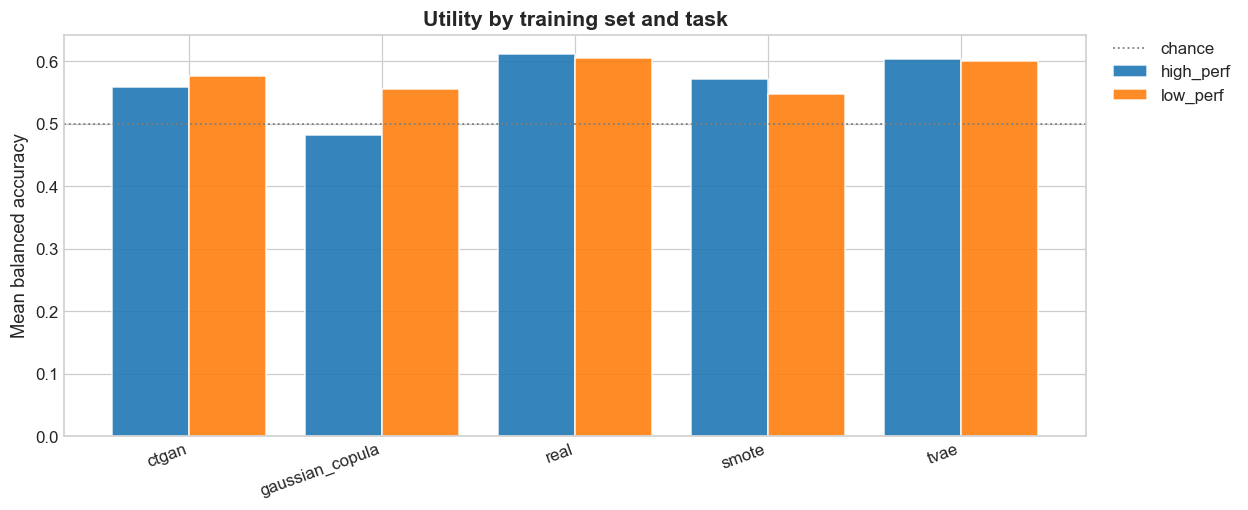

In [5]:
from src.utils.plotting import plot_grouped_bars

plot_grouped_bars(utility, "Mean balanced accuracy",
                  "Utility by training set and task",
                  FIGURES_DIR, "utility_by_task",
                  reference_line=0.5, reference_label="chance")

**Observation.** Every generator costs accuracy on both tails, so the answer to question 1 is
that some loss is unavoidable, and the size of it separates the methods sharply.

The share lost is the number to read, not the raw loss. Balanced accuracy cannot fall below 0.5
without the model becoming anti-correlated with the truth, so the real baseline holds only
about 0.11 of usable signal above chance, and a change that looks small in accuracy points is a
large fraction of everything there was to lose. TVAE gives up 5 to 8 per cent of that band and
is the only method that stays close on both tails. CTGAN and SMOTE give up between a quarter
and more than half depending on the tail. The Gaussian copula gives up more than all of it on the
excellence task, a share above 1, which means it pushed the model past chance to 0.482: it is
not a weak model on that task, it is a broken one, and its fairness numbers in section 4 have
to be read as meaningless rather than good.

Read the two task columns together as well. CTGAN loses 48 per cent of the band on excellence
and 28 on underperformance, and SMOTE does the reverse, 36 against 55. Neither is trustworthy
at the average of the two, and a study measuring only one tail would have ranked them wrongly
for the other.

## 4. Question 2, how much fairness changes

Mean DPD across the circumstances, and the odds ratio that Marrero et al. lead with. For DPD
lower is closer to parity; for the odds ratio, 1 is parity, below 1 means the model finds the
advantaged students more reliably than the disadvantaged ones.

In [6]:
fairness = (
    no_mitigation.groupby(["task", "generator"], observed=True)[["mean_dpd", "mean_odds_ratio"]]
    .mean().round(4)
)
print(fairness.unstack("task").to_string())
save_csv(fairness.reset_index(), RESULTS_DIR / "fairness_by_task.csv")

                 mean_dpd          mean_odds_ratio         
task            high_perf low_perf       high_perf low_perf
generator                                                  
ctgan              0.1754   0.2153          1.0089   2.4061
gaussian_copula    0.0729   0.1284          1.4054   1.7566
real               0.2526   0.2129          0.6033   2.9555
smote              0.1493   0.0908          0.5787   2.4084
tvae               0.3250   0.2146          0.5601   3.4692
2026-07-28 14:38:26 | INFO     | src.data.persistence | Saved 10 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\fairness_by_task.csv


2026-07-28 14:38:26 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\fairness_by_task.png


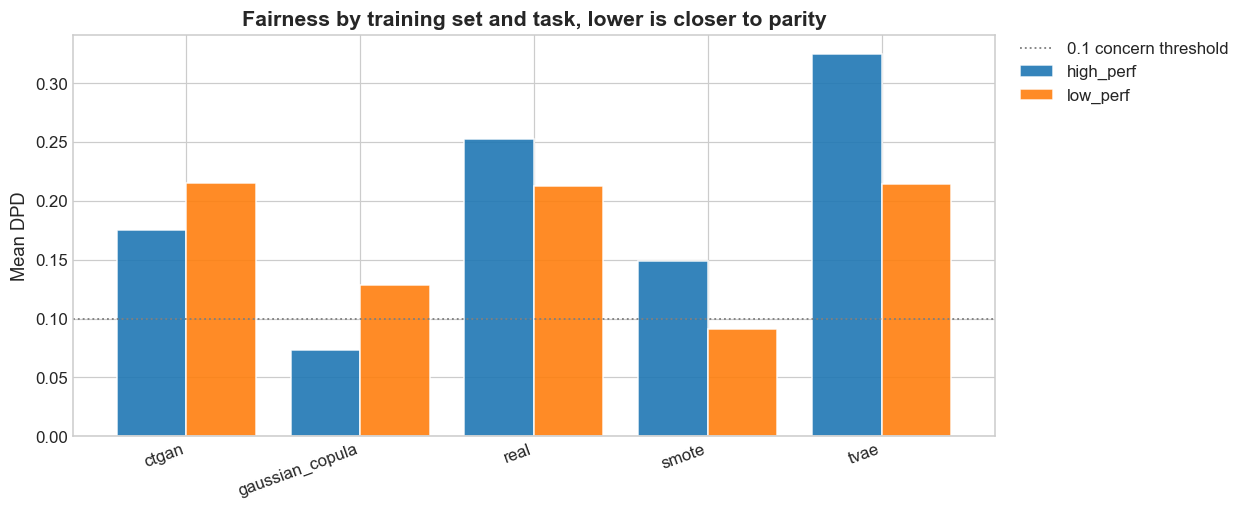

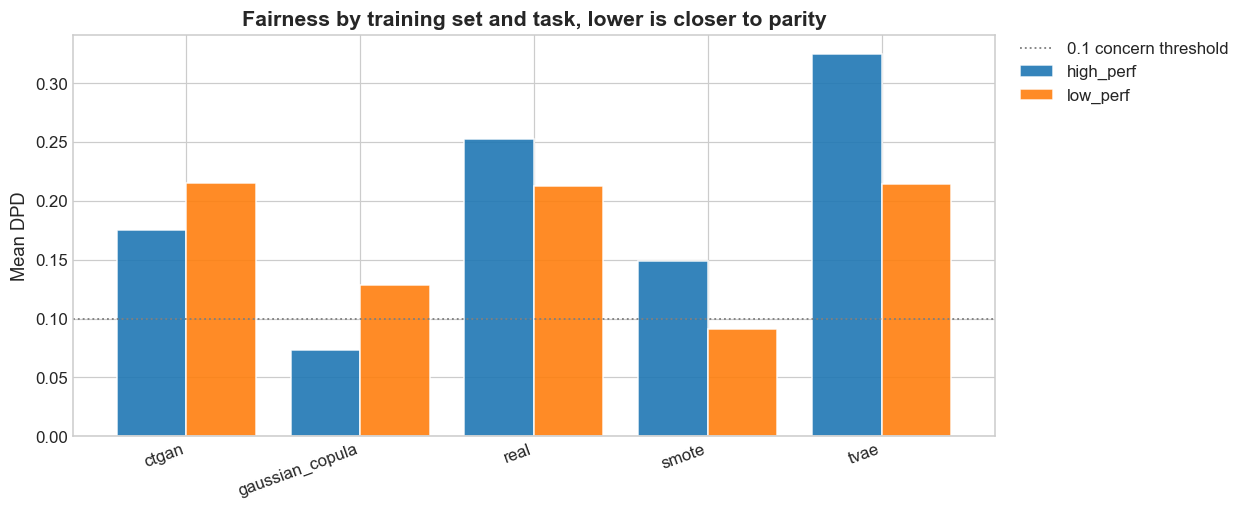

In [7]:
dpd = no_mitigation.groupby(["task", "generator"], observed=True)["mean_dpd"].mean().unstack("task")
plot_grouped_bars(dpd, "Mean DPD",
                  "Fairness by training set and task, lower is closer to parity",
                  FIGURES_DIR, "fairness_by_task",
                  reference_line=cfg["fairness"]["dpd_threshold"],
                  reference_label="0.1 concern threshold")

**Observation.** The real baseline is far from parity on both tasks, DPD 0.25 on excellence and
0.21 on underperformance against a 0.1 concern threshold, and G1 found the same gradient in the
raw scores before any model existed. So what follows measures how synthetic generation
interacts with inequality already in the data, not inequality the pipeline creates.

Most generators appear to improve on that. The copula reaches 0.07 on excellence and SMOTE
0.09 on underperformance, both comfortably inside the threshold the real data fails. Neither is
a fairness gain. The copula scores 0.482 balanced accuracy on that task and SMOTE 0.548, so in
both cases the parity arrives with the model losing its ability to discriminate at all.
Section 5 measures how general that pairing is.

The odds ratio column carries the finding the averages hide. The real baseline reads 0.60 on
excellence and 2.96 on underperformance: the same students, the same features, the same
circumstances, and the model favours opposite groups depending only on which tail it was asked
to detect. Section 8 returns to what that means.

## 5. Question 3, are the two losses related

Each point is one training set and classifier. The interesting region is high accuracy with
low DPD, towards the bottom right.

2026-07-28 14:38:28 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\utility_vs_fairness.png


WindowsPath('C:/Users/tomma/Desktop/petrellirambaldi2526/results/figures/g5/utility_vs_fairness.png')

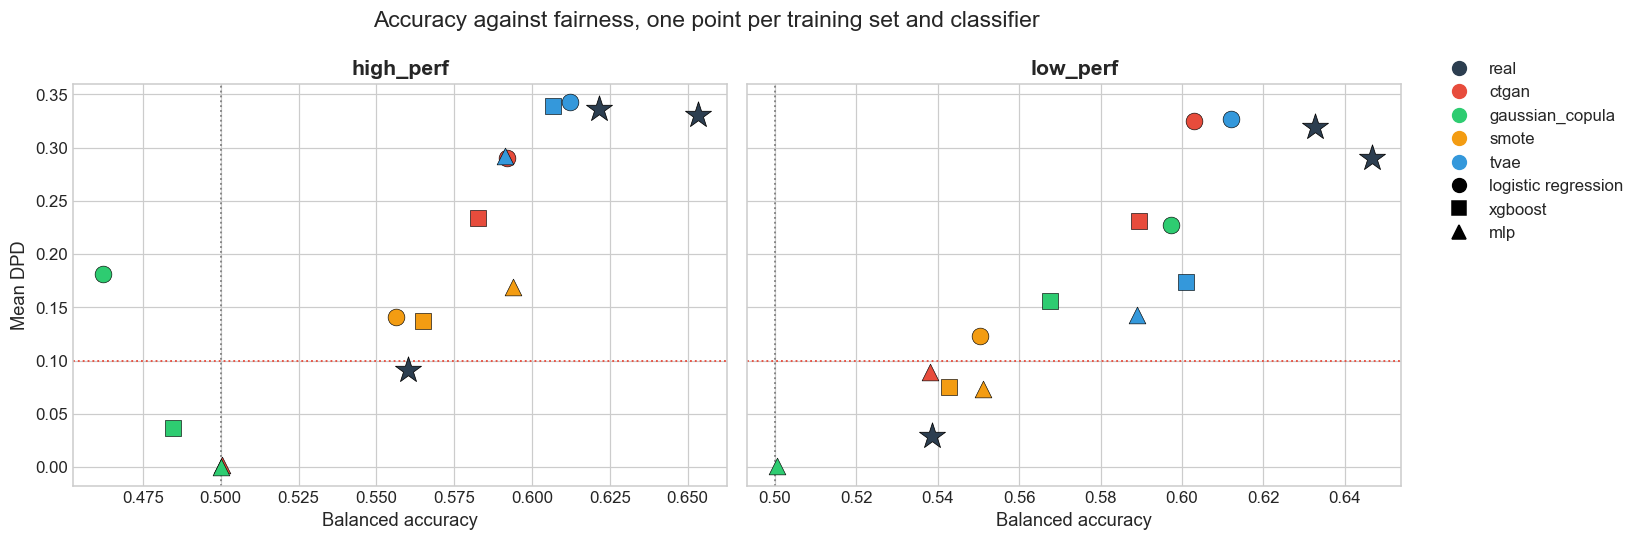

In [8]:
synthetic_only = no_mitigation[no_mitigation["source"] == "synthetic"]

fig, axes = plt.subplots(1, len(TASKS), figsize=(13, 5), sharey=True)
markers = {"logistic_regression": "o", "xgboost": "s", "mlp": "^"}

from src.utils.plotting import colour_for, save_figure

for ax, task in zip(np.atleast_1d(axes), TASKS):
    subset = synthetic_only[synthetic_only["task"] == task]
    real_point = no_mitigation[(no_mitigation["task"] == task) & (no_mitigation["source"] == "real")]
    ax.scatter(real_point["balanced_accuracy"], real_point["mean_dpd"],
               marker="*", s=320, color=colour_for("real"), edgecolors="black",
               linewidths=0.5, zorder=4, label="real")
    for _, row in subset.iterrows():
        ax.scatter(row["balanced_accuracy"], row["mean_dpd"],
                   color=colour_for(row["generator"]),
                   marker=markers.get(row["classifier"], "o"),
                   s=120, edgecolors="black", linewidths=0.4, zorder=3)
    ax.axhline(cfg["fairness"]["dpd_threshold"], color="#e74c3c", ls=":", lw=1.2)
    ax.axvline(0.5, color="grey", ls=":", lw=1.2)
    ax.set_title(task)
    ax.set_xlabel("Balanced accuracy")

np.atleast_1d(axes)[0].set_ylabel("Mean DPD")

handles = [plt.Line2D([], [], marker="o", ls="", markersize=9, color=colour_for(g), label=g)
           for g in ["real"] + sorted(synthetic_only["generator"].unique())]
handles += [plt.Line2D([], [], marker=m, ls="", markersize=9, color="black", label=c.replace("_", " "))
            for c, m in markers.items()]
fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.9), loc="upper left", borderaxespad=0)
fig.suptitle("Accuracy against fairness, one point per training set and classifier")
fig.tight_layout()
save_figure(fig, "utility_vs_fairness", FIGURES_DIR)

In [9]:
# The two changes, paired per training set and classifier, against the matching real row.
paired = []
for task in TASKS:
    subset = no_mitigation[no_mitigation["task"] == task]
    reference = subset[subset["source"] == "real"].set_index("classifier")
    synthetic = subset[subset["source"] == "synthetic"].copy()
    synthetic["accuracy change"] = (
        synthetic["balanced_accuracy"] - synthetic["classifier"].map(reference["balanced_accuracy"])
    )
    synthetic["dpd change"] = (
        synthetic["mean_dpd"] - synthetic["classifier"].map(reference["mean_dpd"])
    )
    paired.append(synthetic[["task", "generator", "classifier", "accuracy change", "dpd change"]])

paired = pd.concat(paired, ignore_index=True)
correlation = paired["accuracy change"].corr(paired["dpd change"])
both_fell = int(((paired["accuracy change"] < 0) & (paired["dpd change"] < 0)).sum())

print(f"Runs compared: {len(paired)}")
print(f"Correlation between the accuracy change and the DPD change: {correlation:.3f}")
print(f"Runs that lost accuracy and lowered DPD together: {both_fell} of {len(paired)}")

Runs compared: 24
Correlation between the accuracy change and the DPD change: 0.897
Runs that lost accuracy and lowered DPD together: 15 of 24


**Observation.** The correlation is 0.90 across the 24 synthetic runs, and 15 of them lost
accuracy and lowered DPD together. That is the answer to question 3, and it is not the
convenient one. Utility loss and fairness gain are not two axes to trade off against each
other; on this data they are one effect measured twice.

The mechanism is the one section 4 flagged. A model pushed towards chance predicts the positive
class at more similar rates in every group, and demographic parity rewards exactly that. The
Gaussian copula is the clearest case: the best DPD in the study, 0.07, from the only model that
scores below chance.

This is a practical warning rather than a caveat on our own numbers. A practitioner who adopts
synthetic data for privacy, observes DPD fall from 0.25 to 0.07, and reports the system as
fairer has read a broken model as a fair one, and nothing in a standard fairness report would
catch it. The defence is the one used throughout these notebooks: never report a parity metric
without the accuracy of the same model beside it.

It also sets up section 7. If weaker models look fairer, then the mitigation result runs
against this correlation rather than with it, which is what makes it the more trustworthy of
the two findings.

## 6. Question 4, does the picture hold on the other tail

The two tasks use the same students, the same features and the same generators. Only the label
changes, from the top quarter to the bottom quarter. So a ranking that survives the switch is a
property of the generator, and one that does not is a property of the task.

In [10]:
ranking = (
    no_mitigation[no_mitigation["source"] == "synthetic"]
    .groupby(["task", "generator"], observed=True)["balanced_accuracy"].mean()
    .unstack("task")
)
ranking["rank " + TASKS[0]] = ranking[TASKS[0]].rank(ascending=False).astype(int)
ranking["rank " + TASKS[1]] = ranking[TASKS[1]].rank(ascending=False).astype(int)
print("Utility ranking of the generators on each task, 1 is best:")
print(ranking.round(4).to_string())

correlation = ranking[TASKS[0]].corr(ranking[TASKS[1]], method="spearman")
print(f"\nRank correlation between the two tasks: {correlation:.2f}")

Utility ranking of the generators on each task, 1 is best:
task             high_perf  low_perf  rank high_perf  rank low_perf
generator                                                          
ctgan               0.5584    0.5768               3              2
gaussian_copula     0.4823    0.5552               4              3
smote               0.5718    0.5481               2              4
tvae                0.6033    0.6006               1              1

Rank correlation between the two tasks: 0.40


**Observation.** Compare the two rank columns, but read the accuracy columns beside them before
concluding anything from a rank. Ranks are ordinal and hide how far apart the generators
actually are; where two of them sit within a hundredth of each other, the rank between them is
not a finding and will not survive another run. Only a generator that is clearly separated from
the others on both tails can be described as ordered at all.

Where the ranks do disagree by a margin worth reporting, the choice of generator depends on
which tail is being predicted, and a practitioner cannot pick one on the basis of a single
task's experiment.

This is the practical payoff of mirroring the task. Marrero et al. show that a model built on
circumstances is biased in opposite directions for the two tails, so a result measured on one
tail alone cannot be assumed to carry over.

## 7. Question 5, does mitigation still work on synthetic data

This is the question with the most direct consequence. G4 measured, for every circumstance, how
much of its gap each technique removed, separately for models trained on real and on synthetic
data. If the two are close, fairness tooling transfers. If not, the privacy motivated switch to
synthetic data has weakened the repair applied afterwards.

In [11]:
comparisons = []
for task in TASKS:
    frame = pd.read_csv(cfg["paths"]["results_dir"] / "g4" / task / "mitigation_comparison.csv")
    frame["task"] = task
    comparisons.append(frame)

comparisons = pd.concat(comparisons, ignore_index=True)
comparisons["source"] = np.where(comparisons["method"] == BASELINE, "real", "synthetic")

effectiveness = (
    comparisons.groupby(["task", "technique", "source"])[
        ["dpd_before", "dpd_after", "dpd_improvement", "eod_improvement",
         "di_improvement", "balanced_accuracy"]
    ].mean()
)
effectiveness["share_closed"] = (
    effectiveness["dpd_improvement"] / effectiveness["dpd_before"]
)
print("Mitigation effectiveness, positive improvement means fairer:")
print(effectiveness.round(4).to_string())
save_csv(effectiveness.reset_index(), RESULTS_DIR / "mitigation_effectiveness.csv")

Mitigation effectiveness, positive improvement means fairer:
                                       dpd_before  dpd_after  dpd_improvement  eod_improvement  di_improvement  balanced_accuracy  share_closed
task      technique         source                                                                                                             
high_perf equalized_odds    real           0.2526     0.0347           0.2180           0.2384          0.4454             0.6182        0.8628
                            synthetic      0.1806     0.0945           0.0861           0.0907          0.2551             0.5440        0.4769
          prejudice_remover real           0.2526     0.0554           0.1973           0.1781         -0.1631             0.5324        0.7809
                            synthetic      0.1806     0.1015           0.0791           0.0797         -0.1694             0.5361        0.4380
low_perf  equalized_odds    real           0.2129     0.0254           0.18

Share of the gap each source closes, and the difference between them:
                            dpd_before           dpd_after           share_closed           shortfall
source                            real synthetic      real synthetic         real synthetic          
task      technique                                                                                  
high_perf equalized_odds        0.2526    0.1806    0.0347    0.0945       0.8628    0.4769    0.3859
          prejudice_remover     0.2526    0.1806    0.0554    0.1015       0.7809    0.4380    0.3429
low_perf  equalized_odds        0.2129    0.1623    0.0254    0.1029       0.8809    0.3660    0.5149
          prejudice_remover     0.2129    0.1623    0.0190    0.0963       0.9108    0.4066    0.5042


2026-07-28 14:38:29 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5\mitigation_real_vs_synthetic.png


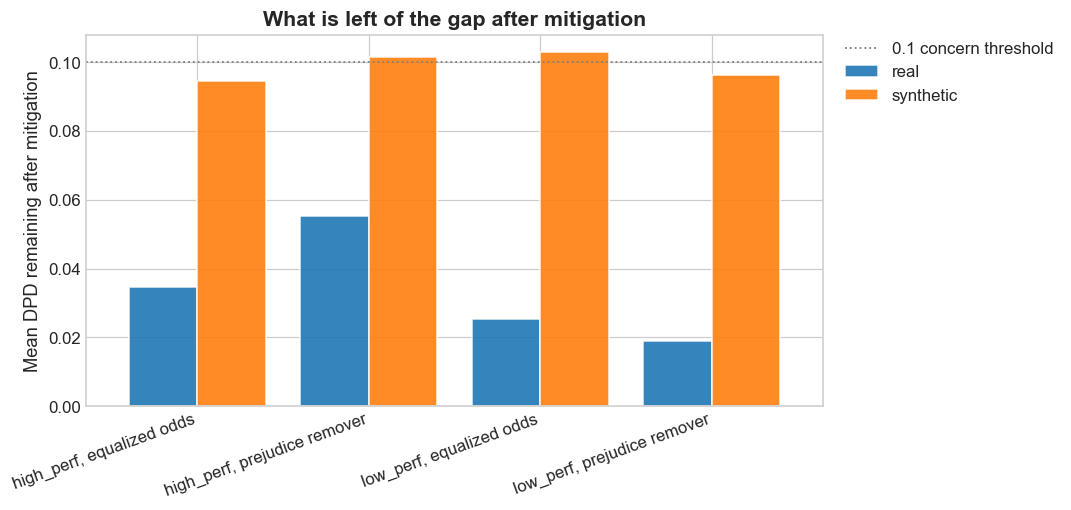

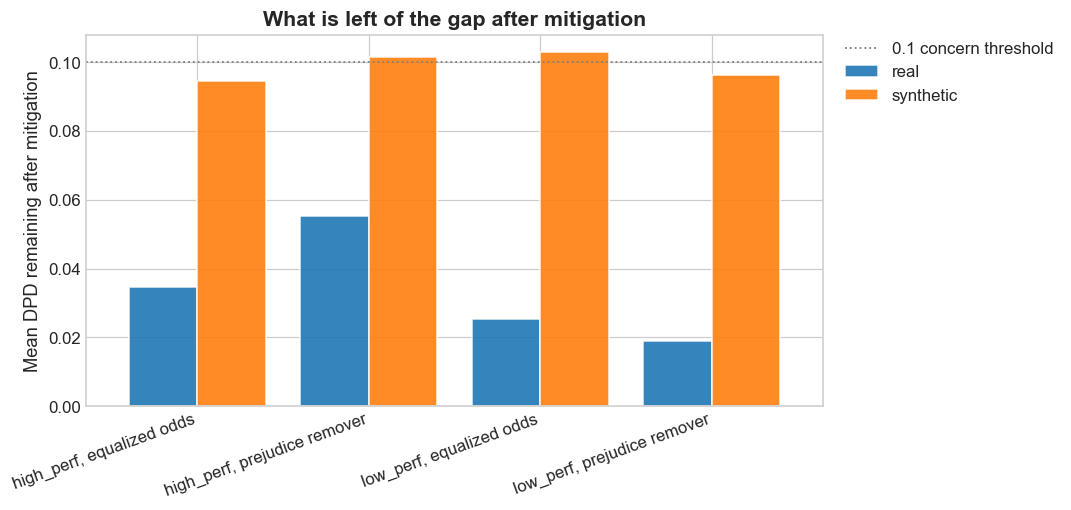

In [12]:
gap = effectiveness[["dpd_before", "dpd_after", "share_closed"]].unstack("source")
gap["shortfall"] = (
    gap[("share_closed", "real")] - gap[("share_closed", "synthetic")]
)
print("Share of the gap each source closes, and the difference between them:")
print(gap.round(4).to_string())

remaining = effectiveness["dpd_after"].unstack("source")
remaining.index = [f"{task}, {technique.replace('_', ' ')}" for task, technique in remaining.index]
plot_grouped_bars(remaining,
                  "Mean DPD remaining after mitigation",
                  "What is left of the gap after mitigation",
                  FIGURES_DIR, "mitigation_real_vs_synthetic",
                  reference_line=cfg["fairness"]["dpd_threshold"],
                  reference_label="0.1 concern threshold")

**Observation.** This is the headline result. On real training data the two techniques remove 78
to 91 per cent of the gap on the circumstance they target. On synthetic training data they
remove 37 to 48 per cent. The shortfall is between 34 and 51 percentage points, and it is
present on both tasks and for both techniques, so it is not a quirk of one configuration.

The obvious objection is that the synthetic models arrive with a smaller gap already, 0.18
against 0.25 on excellence, so a smaller improvement might just mean there was less to remove.
Three quantities are reported together because of it, and they agree. The share closed already
divides out the starting point. And `dpd_after`, the gap a student is actually left with once
the repair has been applied, does not depend on where either source started: it is 0.019 to
0.055 on real data and 0.095 to 0.103 on synthetic, so the synthetic models end up between
roughly two and five times further from parity despite starting closer to it.

That last point is what makes the finding solid. Section 5 showed weaker models look fairer
before mitigation, so the artefact pushes against this result rather than producing it.

The practical statement for the report: fairness tooling does not transfer. A technique
validated on real data will close roughly half as much of the gap once the training data has
been replaced, and the practitioner has no way of knowing that without measuring it again after
the substitution. This is a caution about the workflow rather than an argument against
synthetic data, and it is a direct answer to the question the project set out to ask.

## 8. The two tails mean different things

The odds ratio is the recall of the unprivileged group over the recall of the privileged one,
so unlike the other metrics it has a direction. Below 1 the model finds advantaged students
more reliably, above 1 it finds disadvantaged students more reliably. The table in section 4
already shows the two tasks landing on opposite sides of 1. This counts how general that is,
across the individual circumstances of the real baseline rather than across their average.

In [13]:
sides = []
for task in TASKS:
    directory = cfg["paths"]["results_dir"] / "g3" / task / "per_attribute_fairness"
    for classifier in ["logistic_regression", "xgboost", "mlp"]:
        detail = pd.read_csv(directory / f"fairness_{BASELINE}_{classifier}.csv")
        ratios = detail["odds_ratio"].dropna()
        sides.append({
            "task": task,
            "classifier": classifier,
            "circumstances measured": len(ratios),
            "below 1": int((ratios < 1).sum()),
            "above 1": int((ratios > 1).sum()),
            "median": round(ratios.median(), 3),
        })

print("Direction of the odds ratio per circumstance, real training data:")
print(pd.DataFrame(sides).to_string(index=False))

Direction of the odds ratio per circumstance, real training data:
     task          classifier  circumstances measured  below 1  above 1  median
high_perf logistic_regression                      13       13        0   0.652
high_perf             xgboost                      13       13        0   0.700
high_perf                 mlp                      13       13        0   0.434
 low_perf logistic_regression                      13        0       13   1.688
 low_perf             xgboost                      13        0       13   1.769
 low_perf                 mlp                      13        2       11   2.028


**Observation.** The split is total. On the excellence task all 13 circumstances come out below 1
for all three classifiers, 39 of 39. On underperformance 37 of 39 come out above it. The
direction belongs to the tail, not to a circumstance and not to a classifier.

So the model is not simply less accurate for disadvantaged students. It is systematically less
willing to place them in whichever class it has been asked to detect, whether that class is
the top quarter or the bottom one.

That is what makes the ethical reading depend on the decision the prediction feeds. Used to
award prizes or selective places, a model that recalls advantaged students more reliably
compounds an advantage those students already had. Used to allocate remedial support, the
identical statistic describes who is offered help, and there the group found more reliably is
the disadvantaged one, which is the intended effect rather than a harm.

So neither direction is automatically wrong, and a fairness audit that reports the metric
without naming the decision it serves cannot tell the two cases apart. This is the argument for
running both tails rather than treating the second as a robustness check. It is also a caution
about the project's own numbers: the DPD and EOD figures throughout are symmetric in the two
groups and carry none of this direction, so they should not be read as measuring harm on their
own.

## 9. Summary

In [14]:
print("Real baseline and the cost of each synthetic generator")
for task in TASKS:
    subset = no_mitigation[no_mitigation["task"] == task]
    real_ba = subset.loc[subset["source"] == "real", "balanced_accuracy"].mean()
    real_dpd = subset.loc[subset["source"] == "real", "mean_dpd"].mean()
    print(f"\n{task}: real balanced accuracy {real_ba:.4f}, mean DPD {real_dpd:.4f}")

    per_generator = (
        subset[subset["source"] == "synthetic"]
        .groupby("generator", observed=True)[["balanced_accuracy", "mean_dpd"]].mean()
        .sort_values("balanced_accuracy", ascending=False)
    )
    for generator, row in per_generator.iterrows():
        print(f"  {generator:<16} accuracy {row['balanced_accuracy']:.4f} "
              f"({row['balanced_accuracy'] - real_ba:+.4f})    "
              f"DPD {row['mean_dpd']:.4f} ({row['mean_dpd'] - real_dpd:+.4f})")

Real baseline and the cost of each synthetic generator

high_perf: real balanced accuracy 0.6117, mean DPD 0.2526
  tvae             accuracy 0.6033 (-0.0084)    DPD 0.3250 (+0.0723)
  smote            accuracy 0.5718 (-0.0399)    DPD 0.1493 (-0.1033)
  ctgan            accuracy 0.5584 (-0.0533)    DPD 0.1754 (-0.0772)
  gaussian_copula  accuracy 0.4823 (-0.1294)    DPD 0.0729 (-0.1798)

low_perf: real balanced accuracy 0.6059, mean DPD 0.2129
  tvae             accuracy 0.6006 (-0.0053)    DPD 0.2146 (+0.0017)
  ctgan            accuracy 0.5768 (-0.0291)    DPD 0.2153 (+0.0024)
  gaussian_copula  accuracy 0.5552 (-0.0508)    DPD 0.1284 (-0.0845)
  smote            accuracy 0.5481 (-0.0578)    DPD 0.0908 (-0.1221)


### 9.1 The five questions, answered

**Q1, how much accuracy is lost.** Always some, and how much depends entirely on the generator.
The real baseline holds only about 0.11 of balanced accuracy above chance, and measured against
that band TVAE gives up 5 to 8 per cent, CTGAN and SMOTE between a quarter and a half, and the
Gaussian copula more than all of it on the excellence task, ending below chance at 0.482.

**Q2, how much fairness changes.** It changes on every generator, but almost never in a way
worth having. The real baseline sits at DPD 0.25 on excellence and 0.21 on underperformance,
and most synthetic training sets appear to improve on it, some to inside the 0.1 threshold the
real data fails. Q3 explains why that is not a gain.

**Q3, are the two losses related.** Yes, and more tightly than a trade off. The correlation
between the accuracy change and the DPD change is 0.90 across 24 runs. Demographic parity
rewards a model that has stopped discriminating, so a generator that damages the model is
recorded as improving its fairness. There is no Pareto frontier to choose a position on here;
there is one effect being measured twice.

**Q4, does the answer depend on the tail.** For the direction of the bias, no, and emphatically
so: 39 of 39 circumstance and classifier combinations favour the advantaged group on excellence,
37 of 39 favour the disadvantaged group on underperformance. For the choice of generator, yes.
The utility ranking does not survive the switch of tail, and the gaps that reorder it are small
enough that they would not survive a re-run either.

**Q5, does mitigation still work on synthetic data.** Only about half as well. The two
techniques close 78 to 91 per cent of the targeted gap on real training data and 37 to 48 per
cent on synthetic, leaving a residual gap of 0.10 rather than 0.02 to 0.06. The effect holds on
both tasks and both techniques, and it survives the objection that the synthetic models started
closer to parity.

The single sentence a practitioner should take away: replacing real training data with
synthetic data does not merely cost accuracy, it quietly weakens the fairness tooling applied
afterwards, and it does so while making the standard fairness metrics look better.

## 10. Limitations

Carried forward from the earlier notebooks and stated here so the conclusions above are read
with them in mind.

- The circumstances are heavily unanswered, up to most of the test set for country of birth.
  Every fairness number for those attributes is computed on the students who did answer, and
  those students are not a random sample of the population.
- `mean_odds_ratio` is a ratio of two recalls and becomes volatile when a group has few
  positive cases. A support floor suppresses the worst of it, but prefer DPD, EOD and DI when
  the two disagree.
- A row flagged `degenerate_predictions` predicted a single class for the whole test set. Its
  DPD of zero is arithmetic, not fairness.
- The MLP is the least stable of the three classifiers and is the one that collapses to a
  single class when the training data is poor. Conclusions that rest on the MLP alone are
  weaker than those visible in all three.
- The feature set was selected by mutual information against the excellence target and then
  used for both tasks. Holding it fixed is what makes the two tasks comparable, but the
  selection itself was made with one of them in mind.
- One split throughout, and no confidence intervals, so small gaps between generators should
  not be over read.
- CTGAN and TVAE are not reproducible. The seed in `config.yaml` reaches the split, the
  classifiers and SMOTE, but the SDV synthesizers train under torch without one, so refitting
  them gives a different synthetic dataset each time. We have two complete runs of identical
  code and they differ by up to 0.011 balanced accuracy for CTGAN and 0.007 for TVAE, while the
  copula reproduces exactly. CTGAN's synthetic underperformance rate moved from 17 to 37 per
  cent between the two. So the gap between real and synthetic training data, which is 0.03 to
  0.13, is comfortably larger than this variation, but the ordering of the deep generators
  against each other and against SMOTE is not, and neither is any single target rate quoted
  for them.